In [8]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from astropy.io import fits
import numpy.ma as ma
from scipy.optimize import curve_fit

import sys
sys.path.insert(1, '/Users/nityaravi/Documents/GitHub/RotationCurves/spirals/')

from DRP_vel_map_functions import deproject_spaxel
from metallicity_map_functions import linear_metallicity_gradient

from DRP_rotation_curve import extract_data

## data

In [9]:
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
p3d_folder = DATA_FOLDER + '/Pipe3D/'

master_table_fn = DATA_FOLDER + '/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v11_gradZ.fits'

In [10]:
master_table = Table.read(master_table_fn)

In [11]:
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,

In [12]:
master_table_dict = {}
for i in range(len(master_table)):

    master_table_dict[master_table['plateifu'][i]] = i
    

In [13]:
test_galaxy = '10001-9102'
q0 = 0.2
ln10 = ma.log(10)
H_0 = 100      # Hubble's Constant in units of h km/s/Mpc
c = 299792.458 # Speed of light in units of km/s
MANGA_SPAXEL_SIZE = 0.5*(1/60)*(1/60)*(np.pi/180)  # spaxel size (0.5") in radians
fHep = 0.2485 # primordial Helium fraction

## plot stellar metallicity map

In [15]:
file_name = p3d_folder + 'manga-' + test_galaxy + '.Pipe3D.cube.fits.gz'

cube = fits.open(file_name)

In [16]:
stellar_z = cube[1].data[8]
stellar_z_err = cube[1].data[10]

flux = cube[1].data[0]

Text(0, 0.5, 'spaxel')

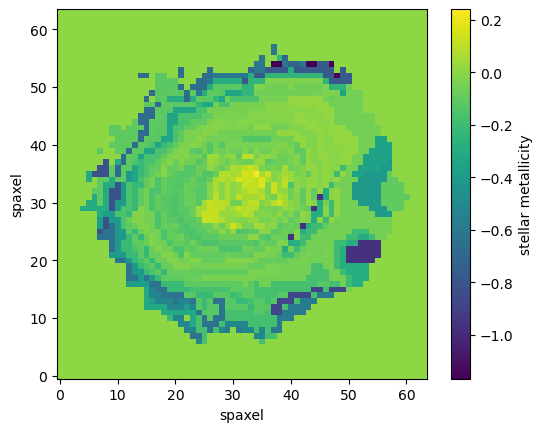

In [17]:
plt.imshow(stellar_z)
plt.colorbar(label='stellar metallicity')
plt.gca().invert_yaxis()
plt.xlabel('spaxel')
plt.ylabel('spaxel')

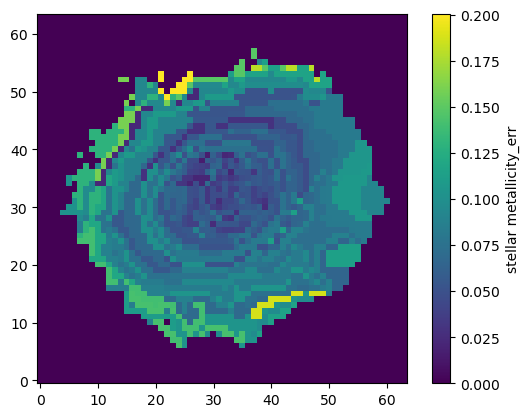

In [18]:
plt.imshow(stellar_z_err)
plt.gca().invert_yaxis()
plt.colorbar(label='stellar metallicity_err')

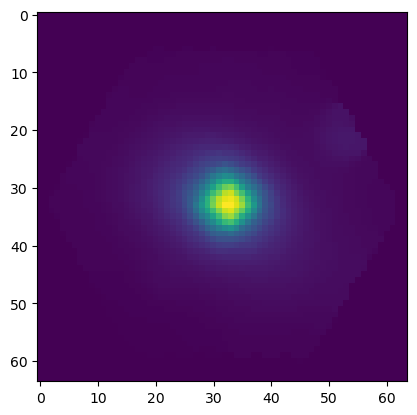

In [19]:
plt.imshow(cube[1].data[0])

In [20]:
test_mask = stellar_z == 0

In [22]:

idx = master_table_dict[test_galaxy]
center = (master_table['x0'][idx], master_table['y0'][idx])

phi = master_table['phi'][idx]

ba = master_table['ba'][idx]


cosi2 = (ba**2 - q0**2)/(1 - q0**2)
i_angle = np.arccos(np.sqrt(cosi2))

z = master_table['z'][idx]


dist_to_galaxy_Mpc = c*z/H_0
dist_to_galaxy_kpc = dist_to_galaxy_Mpc*1000
pix_scale_factor = dist_to_galaxy_kpc*np.tan(MANGA_SPAXEL_SIZE)

r_kpc = np.zeros((len(stellar_z), len(stellar_z[0])))


for i in range(len(stellar_z)):
    for j in range(len(stellar_z[0])):

        r_spax, _ = deproject_spaxel((i,j), center, phi, i_angle)
        r_kpc[i][j] = r_spax*pix_scale_factor

/Users/nityaravi/Documents/GitHub/RotationCurves/spirals/DRP_vel_map_functions.py:490: UserWarning: Warning: converting a masked element to nan.
  delta = np.subtract(coords, center)
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_8116/3408363386.py:26: UserWarning: Warning: converting a masked element to nan.
  r_kpc[i][j] = r_spax*pix_scale_factor


In [38]:
ma.is_masked(center[0])

True

Text(0, 0.5, 'stellar metallicity')

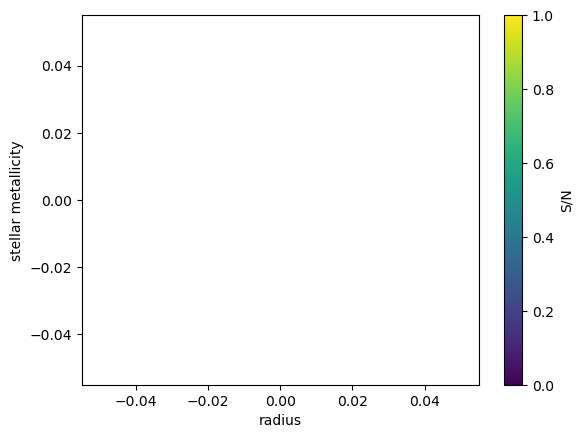

In [25]:
plt.scatter(r_kpc, stellar_z)
plt.colorbar(label='S/N')
plt.xlabel('radius')
plt.ylabel('stellar metallicity')
# plt.axhline(0)

In [134]:
sn_5 = np.abs(stellar_z / stellar_z_err) > 5

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_2865/3479857350.py:1: RuntimeWarning: invalid value encountered in divide
  sn_5 = np.abs(stellar_z / stellar_z_err) > 5


In [137]:
stellar_z_masked = stellar_z[sn_5]
r_masked = r_kpc[sn_5]

In [138]:
plt.scatter(r_masked, stellar_z_masked, c = )

SyntaxError: expected argument value expression (3253625412.py, line 1)

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_2865/1054134118.py:1: RuntimeWarning: invalid value encountered in divide
  plt.hist(np.abs(stellar_z).flatten()/stellar_z_err.flatten(), bins = np.linspace(0,60,60))


Text(0.5, 0, 'S/N')

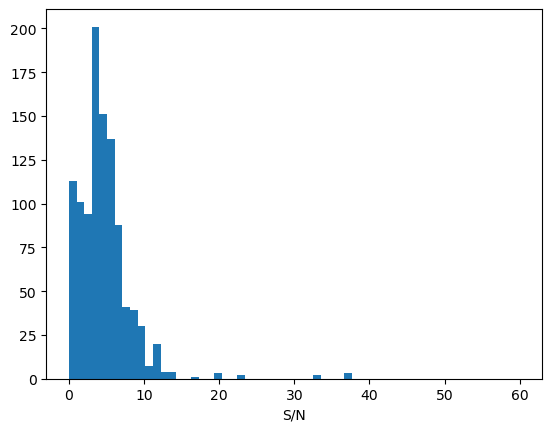

In [139]:
plt.hist(np.abs(stellar_z).flatten()/stellar_z_err.flatten(), bins = np.linspace(0,60,60))
plt.xlabel('S/N')

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_2865/3621087136.py:1: RuntimeWarning: invalid value encountered in divide
  plt.imshow(np.abs(stellar_z)/stellar_z_err, vmin=0, vmax=20)


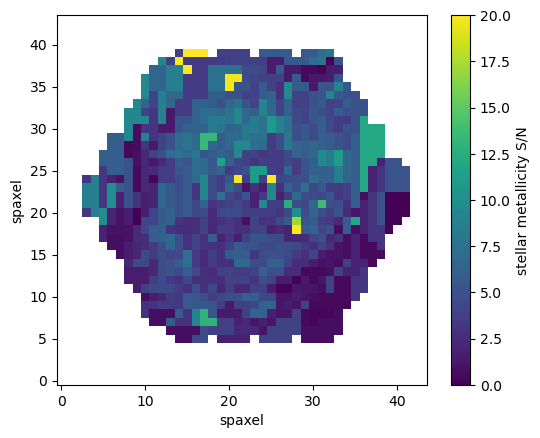

In [140]:
plt.imshow(np.abs(stellar_z)/stellar_z_err, vmin=0, vmax=20)
plt.colorbar(label='stellar metallicity S/N')
plt.xlabel('spaxel')
plt.ylabel('spaxel')
plt.gca().invert_yaxis()

In [141]:
flux_mask = flux > 0

In [142]:
stellar_z.shape

(44, 44)

In [143]:
stellar_z_fmask = ma.array(stellar_z, mask=~flux_mask)

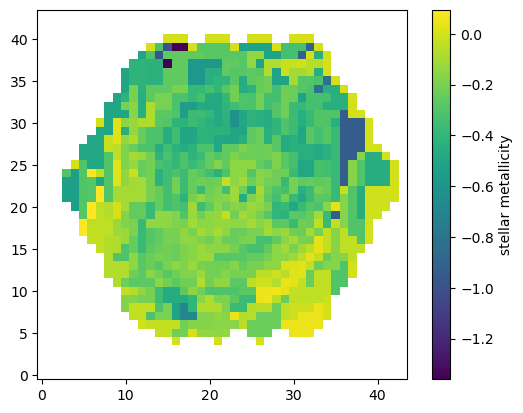

In [144]:
plt.imshow(stellar_z_fmask.reshape(44,44))
plt.colorbar(label='stellar metallicity')
plt.gca().invert_yaxis()

In [145]:
dist_to_galaxy_Mpc

82.525069083492

In [146]:
# get the default mask from sdss dr17
vel_maps = extract_data(DATA_FOLDER + '/DR17/', test_galaxy, 'Ha_vel')

In [147]:
Ha_vel = ma.array(vel_maps['Ha_vel'], mask = vel_maps['Ha_vel_mask'])

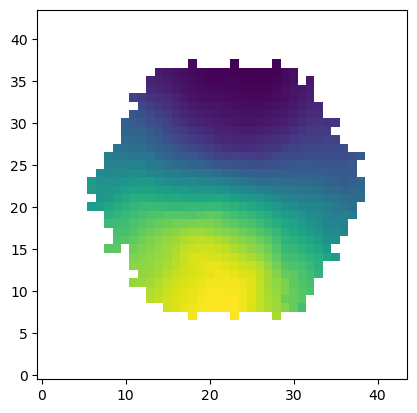

In [148]:
plt.imshow(Ha_vel)
plt.gca().invert_yaxis()

In [149]:
stel_met_vel_mask = ma.array(stellar_z, mask=vel_maps['Ha_vel_mask'])

Text(0, 0.5, 'spaxel')

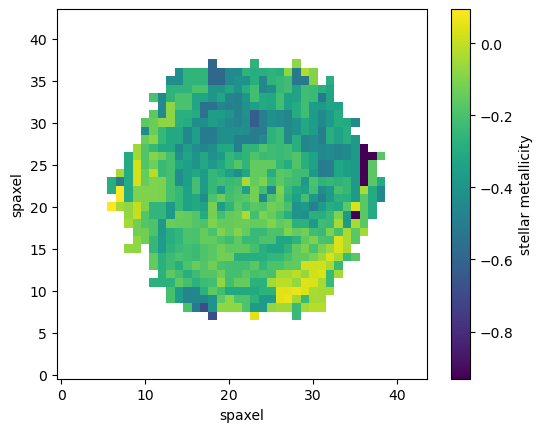

In [150]:
plt.imshow(stel_met_vel_mask)
plt.gca().invert_yaxis()
plt.colorbar(label='stellar metallicity')
plt.xlabel('spaxel')
plt.ylabel('spaxel')

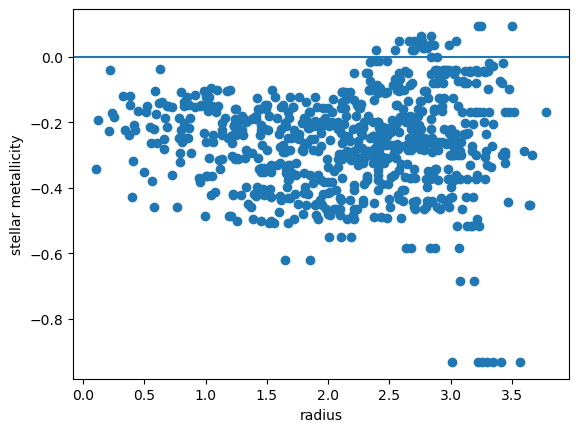

In [151]:
plt.scatter(r_kpc, stel_met_vel_mask)
plt.xlabel('radius')
plt.ylabel('stellar metallicity')
plt.axhline(0)

In [152]:
# try median binning these 

r_flat = ma.array(r_kpc, mask=vel_maps['Ha_vel_mask']).compressed()
m = stel_met_vel_mask.compressed()
m_sigma = ma.array(stellar_z_err, mask=vel_maps['Ha_vel_mask']).compressed()

bin_edges = np.linspace(0, np.max(r_flat), 15)
step_size = (bin_edges[0] + bin_edges[1]) / 2
bin_centers = bin_edges[:-1] + step_size 

m_median = np.zeros(len(bin_centers))
m_sigma_med = np.zeros(len(bin_centers))

for i in range(0, len(bin_centers)):

    if i == 0:
        vals = m[np.logical_and(r_flat >= bin_edges[i], r_flat <= bin_edges[i+1])]
        sigmas = m_sigma[np.logical_and(r_flat >= bin_edges[i], r_flat <= bin_edges[i+1])]
    
    else:
        vals = m[np.logical_and(r_flat > bin_edges[i], r_flat <= bin_edges[i+1])]
        sigmas = m_sigma[np.logical_and(r_flat > bin_edges[i], r_flat <= bin_edges[i+1])]


    m_median[i] = ma.median(vals)
    stddev = ma.std(vals)
    N = len(vals)

    if N != 1:
        m_sigma_med[i] = stddev*ma.sqrt(2*np.pi*N/(N-1))

    if N == 1:
        m_sigma_med[i] = sigmas[0]

    # m_sigma_med = stddev


print('m_med', m_median)
print('m_sigma_med', m_sigma_med)

m_med [-0.18775643 -0.2090833  -0.22164605 -0.18789762 -0.23773053 -0.31519161
 -0.28297332 -0.26316294 -0.25698236 -0.22906332 -0.23860411 -0.27282
 -0.2207885  -0.30007857]
m_sigma_med [0.24503407 0.23542962 0.25172862 0.26673442 0.26225778 0.30161703
 0.28721957 0.31359606 0.3247535  0.34000184 0.41472647 0.48796213
 0.66973062 0.66138897]


In [153]:
try:
    popt, pcov = curve_fit(linear_metallicity_gradient, 
                                    bin_centers, 
                                    m_median,
                                    sigma=m_sigma_med
                                    )

except:
    print('fit failed')
    

In [154]:
popt

array([-0.02447148, -0.20225747])

In [155]:
pcov

array([[ 9.0223602e-05, -1.2366330e-04],
       [-1.2366330e-04,  2.4758719e-04]])

Text(0, 0.5, 'stellar metallicity')

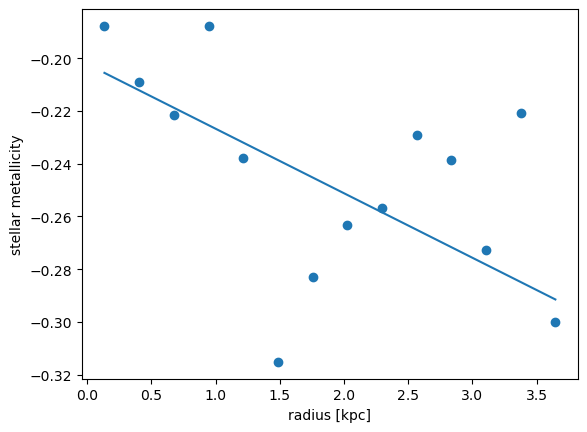

In [156]:
plt.scatter(bin_centers,m_median)
plt.plot(bin_centers, bin_centers*popt[0] + popt[1])
plt.xlabel('radius [kpc]')
plt.ylabel('stellar metallicity')

In [2]:
# file_name = p3d_folder + 'manga-' + test_galaxy + '.Pipe3D.cube.fits.gz'

cube = fits.open('/Users/nityaravi/Desktop/manga-7495-6101.Pipe3D.SSP.fits.gz')

In [5]:
cube[0].data

array([[[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       ...,

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan